# osm_LoD1_3DCityModel *(No Internet)*

[![Binder](_static/launch-binder.svg)](https://mybinder.org/v2/gh/AdrianKriger/geo3D_wrkshp/HEAD?urlpath=%2Fdoc%2Ftree%2Fworkshop%2Fnotebooks%2Fosm_LoD1_3D-noInternet.ipynb)
 
<div class="alert alert-block alert-info""><b>This is a stand-alone Notebook for use in low resource settings. NO internet connection is necessary.</b> 

<br>
<br>

While an internet connection is **NOT** necessary you will **NEED** to have sourced an **[osm.pbf](https://wiki.openstreetmap.org/wiki/PBF_Format)**.</div>

**The purpose of this notebook is to walk a user through [osm_LoD1_3DCityModel](https://github.com/AdrianKriger/osm_LoD1_3DCityModel/tree/main/village_campus).**


<div class="alert alert-block alert-warning"><b>This notebook will:</b>

> **1. allow the user to create a Level-of-Detail 1 (LoD1) [3D City Model](https://en.wikipedia.org/wiki/3D_city_model).**  
>
> **2. propose several Geography and Sustainable Development Education *conversation starters* for Secondary and Tertiary level students**
</div>

<div class="alert alert-block alert-danger"><b></b>

***The [suburb](https://github.com/AdrianKriger/geo3D/tree/main/suburb)*** processing option is meant for areas with more than for **2 500 buildings**.</div>

In [1]:
import time
from datetime import timedelta
import tempfile

import os
from itertools import chain
import math

import requests
import overpass
import osm2geojson

import numpy as np
import pandas as pd
import geopandas as gpd
import topojson as tp

from shapely.geometry import polygon
from shapely.geometry import Point, Polygon 
from shapely.ops import snap
from shapely.ops import transform
from shapely.strtree import STRtree

import copy
import json

import pyproj

import city3D

from osgeo import gdal, ogr, osr

import triangle as tr

from openlocationcode import openlocationcode as olc

import matplotlib.pyplot as plt

In [2]:
Tstart = time.time()

import warnings
warnings.filterwarnings('ignore')

**A `parameter.json` defines the path and files**.

In [3]:
jparams = json.load(open('osm3DwStock_param.json'))         
#jparams = json.load(open('osm3DsRiver_param25m.json'))       
#jparams = json.load(open('osm3Dsaao_param.json'))       

| area of interest | elevation model | CityJSON and metadata |
|:--------:|:--------:|:--------:|
|![area.png](_static/area.png)|![raster.png](_static/raster.png)|![meta.png](_static/meta.png) |

**Harvest [OpenStreetMap](https://en.wikipedia.org/wiki/OpenStreetMap)** - interogate an osm.pbf (["Protocolbuffer Binary Format"](https://wiki.openstreetmap.org/wiki/PBF_Format)) from within Jupyter and convert to .geojson.

<div class="alert alert-block alert-info"><b></b> 
    
**PLEASE SUPPLY YOUR OWN [osm.pbf](https://wiki.openstreetmap.org/wiki/PBF_Format).**  

**Either crop an area directly from [OpenStreetMap]() with the ***[official tool](https://www.openstreetmap.org/export#map=3/0.70/22.15)***, select a predefined area [from any number of providers](https://wiki.openstreetmap.org/wiki/Planet.osm), such as ***[Geofabrik](https://download.geofabrik.de)***, or...**
</div>

<div class="alert alert-block alert-success"><b></b>
    
**... download your own. Provincial extracts for South Africa are available here:** *http://download.openstreetmap.fr/extracts/africa/south_africa/*</div>

In [4]:
# Input OSM PBF file
input_pbf = "./data/CapeTownNew.osm.pbf"
#input_pbf = "./data/south-africa-latest.osm.pbf"

# GeoPackage file [will be created]
#output_gpkg = "./data/output_polygons.gpkg"

**Lets first harvest the boundary of the area; we want to interogate**

In [5]:
start = time.time()

aoi = city3D.extract_boundaries_by_name(input_pbf, jparams)#, country='yes', place_type='neighbourhood')

end = time.time()
print('runtime:', str(timedelta(seconds=(end - start))))

# Drop rows where geometry is None or NaN
aoi = aoi.dropna(subset=['geometry'])
aoi = aoi.set_crs(4326, allow_override=True)

# gt the bounding box (BBOX) of the GeoJSON boundary
minx, miny, maxx, maxy = aoi.total_bounds
bbox_filter = "-spat", str(minx), str(miny), str(maxx), str(maxy)
aoi.head(2)

RuntimeError: ./data/CapeTownNew.osm.pbf: No such file or directory

In [17]:
aoi

,geometry


**Only harvest what we need from the osm.pbf.**

In [6]:
start = time.time()

gdal.UseExceptions()
gdal.SetConfigOption("OGR_GEOMETRY_ACCEPT_UNCLOSED_RING", "NO") 
#gdal.SetConfigOption("USE_CUSTOM_INDEXING", "NO")
# Input OSM PBF file
#input_pbf = "your_data.osm.pbf"

# GDAL Virtual File System (VSI) to avoid writing to disk
geojson_vsimem = "/vsimem/temp.geojson"

#- GDAL VectorTranslate to extract only buildings & fix geometries
gdal.VectorTranslate(
    geojson_vsimem,                                           # Output as in-memory GeoJSON
    input_pbf,                                                # Source OSM PBF file
    format="GeoJSON",                                         # Output format
    layers=["multipolygons"],                                 # Extract only multipolygons
    options=["-where", "building IS NOT NULL", "-makevalid", 
                          "-spat", str(minx), str(miny), str(maxx), str(maxy)]  # Filter buildings & fix geometries
)

#- load into GeoDataFrame
gdf = gpd.read_file(geojson_vsimem)

#- cleanup VSI Memory
gdal.Unlink(geojson_vsimem)

# show gdf
#gdf.head()

end = time.time()
print('runtime:', str(timedelta(seconds=(end - start))))

runtime: 0:00:01.081459


In [7]:
gdf.head(2)
#len(gdf)

,osm_id,osm_way_id,name,amenity,type,building,office,sport,other_tags,geometry
0,13665513,NaN,NaN,NaN,multipolygon,apartments,NaN,NaN,"""addr:city""=>""Cape Town"",""addr:housename""=>""Up...","MULTIPOLYGON (((18.45714 -33.93530, 18.45709 -..."
1,13705114,NaN,NaN,NaN,multipolygon,warehouse,NaN,NaN,"""addr:city""=>""Cape Town"",""addr:housenumber""=>""...","MULTIPOLYGON (((18.44997 -33.93634, 18.45045 -..."


In [8]:
# Convert valid strings, ignore None/NaN
def safe_convert(tag_string):
    if isinstance(tag_string, str):
        try:
            # Replace "=>" with ":" and fix newlines
            formatted_string = "{" + tag_string.replace("=>", ":").replace("\n", " ") + "}"
            return json.loads(formatted_string)  # Parse safely
        except json.JSONDecodeError:
            return {}  # Return empty dict on failure
    return {}  # Return empty dict if NaN or None

# Apply conversion function
gdf["tags"] = gdf["other_tags"].apply(safe_convert)

# Extract values safely - Normalize the 'tags' column to create a new DataFrame
tags_df = pd.json_normalize(gdf['tags'])
# Join the new columns back to the original GeoDataFrame
gdf = pd.concat([gdf, tags_df], axis=1)
# (Optional) Drop the original 'tags' column
gdf = gdf.drop(columns=['other_tags'])

# Ensure a single 'osm_id' column
if 'osm_id' in gdf.columns:
    if 'osm_way_id' in gdf.columns:
        gdf['osm_id'] = [o if pd.notna(o) else w 
                         for o, w in zip(gdf['osm_id'], gdf['osm_way_id'])]
        gdf = gdf.drop(columns=['osm_way_id'])
elif 'osm_way_id' in gdf.columns:
    gdf = gdf.rename(columns={'osm_way_id': 'osm_id'})

gdf = gdf[gdf.geometry.apply(lambda x: x.within(aoi.unary_union))]
gdf.head(2)

,osm_id,name,amenity,type,building,office,sport,geometry,tags,addr:city,...,ref:ZA:emis,school,building:prefabricated,access,female,club,cuisine,opening_hours,outdoor_seating,layer
1,13705114,NaN,NaN,multipolygon,warehouse,NaN,NaN,"MULTIPOLYGON (((18.44997 -33.93634, 18.45045 -...","{'addr:city': 'Cape Town', 'addr:housenumber':...",Cape Town,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,739615941,NaN,NaN,NaN,house,NaN,NaN,"MULTIPOLYGON (((18.44961 -33.93777, 18.44955 -...","{'addr:city': 'Cape Town', 'addr:housenumber':...",Cape Town,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [9]:
ts = gdf[gdf['building'].notna()]
#len(ts)
print('\n', len(ts), "buildings have been harvested from", input_pbf)


 306 buildings have been harvested from ./data/CapeTown.osm.pbf


In [10]:
ts.head(2)

,osm_id,name,amenity,type,building,office,sport,geometry,tags,addr:city,...,ref:ZA:emis,school,building:prefabricated,access,female,club,cuisine,opening_hours,outdoor_seating,layer
1,13705114,NaN,NaN,multipolygon,warehouse,NaN,NaN,"MULTIPOLYGON (((18.44997 -33.93634, 18.45045 -...","{'addr:city': 'Cape Town', 'addr:housenumber':...",Cape Town,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,739615941,NaN,NaN,NaN,house,NaN,NaN,"MULTIPOLYGON (((18.44961 -33.93777, 18.44955 -...","{'addr:city': 'Cape Town', 'addr:housenumber':...",Cape Town,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [11]:
# basic cleaning to harvest building=* (no building:part=*) and building=levels tags only

#- we only want buildings with =levels data
ts = (
    ts.dropna(subset=['building:levels'])
      .assign(**{'building:levels': pd.to_numeric(ts['building:levels'], errors='coerce')})
      .query("`building:levels` != 0")
)

#ts.dropna(subset=['building:levels'], inplace= True)
#ts['building:levels'] = pd.to_numeric(ts['building:levels'], downcast='integer')
#ts['building:levels'] = ts['building:levels'].astype(int)
#- we only want buildings with =levels data
#ts = ts[ts['building:levels'] != 0]
#ts['building:levels'] = ts['building:levels'].replace('None', np.nan)#, inplace=True)
#ts = ts[ts['building:levels'].notna()]

#- without building:part
#ts = ts[ts['building:part'].isnull()]
ts = ts[ts.get("building:part").isnull()] if "building:part" in ts else ts
#ts = ts.explode()
print('\n\033[1m', jparams['FocusArea'], 'has \033[0m', len(ts), 'buildings')


 University Estate has  305 buildings


In [12]:
# have a look
ts.tail(2)

,osm_id,name,amenity,type,building,office,sport,geometry,tags,addr:city,...,ref:ZA:emis,school,building:prefabricated,access,female,club,cuisine,opening_hours,outdoor_seating,layer
415,1025219392,NaN,NaN,NaN,garage,NaN,NaN,"MULTIPOLYGON (((18.44891 -33.93753, 18.44904 -...",{'building:levels': '2'},NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
496,1311778266,NaN,NaN,NaN,office,financial,NaN,"MULTIPOLYGON (((18.45093 -33.93753, 18.45085 -...","{'addr:city': 'Cape Town', 'addr:housename': '...",Cape Town,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
#- coordinate reference system
ts.crs

<img src="_static/proj.png" alt="proj" width="550" align="right"/>
<br>
<br>

We need the ***Projected*** Coordinate Reference System.  

In [ ]:
#- estimate utm: internal geopandas function
ts.estimate_utm_crs()

<div class="alert alert-block alert-danger"><b>Your Participation! </b>
    
**Fill in the proper `espg` in the _`cell`_ below** </div>

In [15]:
#- fill <Projected CRS: EPSG:32734> from above here epsg = EPSG:32734
epsg = 'EPSG:32734'

In [16]:
#project blds
ts = ts.to_crs(epsg)
#project aoi
aoi = aoi.to_crs(epsg)

## 1. Create LoD1 3D City Model

**Now we process.** 

In [17]:
aoibuffer = aoi.copy()

def buffer01(row):
    with np.errstate(invalid='ignore'):
        return row.geometry.buffer(150, cap_style=3, join_style=2)

aoibuffer['geometry'] = aoibuffer.apply(buffer01, axis=1)

##- orient segments and simplify topology
#topo = tp.Topology(aoibuffer, prequantize=False, winding_order='CCW_CW')
#with np.errstate(invalid='ignore'):
    #aoibuffer = topo.toposimplify(0.25).to_gdf()
    
extent = [aoibuffer.total_bounds[0] - 250, aoibuffer.total_bounds[1] - 250, 
          aoibuffer.total_bounds[2] + 250, aoibuffer.total_bounds[3] + 250]

**Now the DEM**  
*one is available at [raster](https://github.com/AdrianKriger/geo3D/suburb/tree/main/raster)*

In [18]:
gdal.SetConfigOption("GTIFF_SRS_SOURCE", "GEOKEYS")
gdal.UseExceptions() 

# set the path and nodata
OutTile = gdal.Warp(jparams['projClip_raster'], 
                    jparams['in_raster'],
                    dstSRS=epsg,
                    srcNodata = jparams['nodata'],
                    #-  dstNodata = 0,
                    #-- outputBounds=[minX, minY, maxX, maxY]
                    outputBounds = [extent[0], extent[1], extent[2], extent[3]])
OutTile = None 

In [19]:
#- convert raster to XYZ in-memory

#- virtual in-memory path
xyz_mem_path = "/vsimem/temp_xyz.xyz"  
gdal.Translate(xyz_mem_path, jparams['projClip_raster'], format="XYZ")  

#- read XYZ from GDAL's in-memory file
xyz_vsimem = gdal.VSIFOpenL(xyz_mem_path, "rb")
xyz_bytes = gdal.VSIFReadL(1, gdal.VSIStatL(xyz_mem_path).size, xyz_vsimem)
gdal.VSIFCloseL(xyz_vsimem)
#- cleanup in-memory file
gdal.Unlink(xyz_mem_path) 

0

**Buildings**

In [20]:
#- harvest buildings
#ts.drop(ts.index[ts['type'] == 'node'], inplace = True)

#- orient segments and simplify topology
topo = tp.Topology(ts, prequantize=False, winding_order='CCW_CW')
with np.errstate(invalid='ignore'):
    ts = topo.toposimplify(0.25).to_gdf()

In [21]:
# prepare to plot (more buildings = more time) 
start = time.time()

ts_copy = ts.copy()
new_df1 = ts_copy.loc[ts_copy.overlaps(ts_copy.unary_union)].reset_index(drop=True)  #-- perhaps no union?

end = time.time()
print('runtime:', str(timedelta(seconds=(end - start))))

runtime: 0:00:00.369401


**Plot**

*Browse the saved `'./data/topologyFig'` at your leisure*

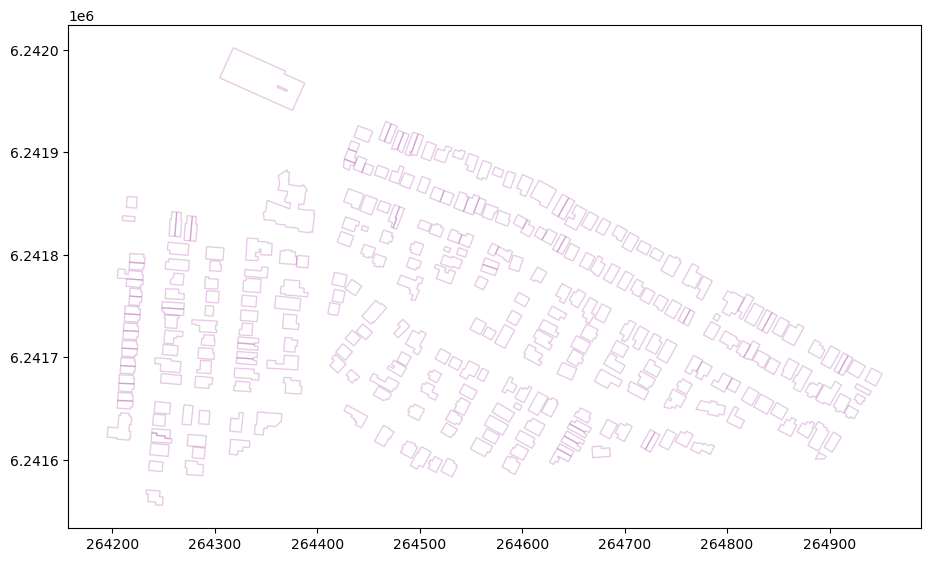

In [22]:
#%matplotlib

fig, ax = plt.subplots(figsize=(11, 11))

ts.plot(ax=ax, facecolor='none', edgecolor='purple', alpha=0.2)
if len(new_df1) > 0:
    new_df1.plot(ax=ax, edgecolor='red', facecolor='none')#, alpha=0.3)#, column='osm_building', legend=True)

#-- save
plt.savefig('./data/topologyFig', dpi=300)
#plt.show()

|  |  |
|:--------:|:--------:|
|![ue-error.png](_static/ue-error.png)| **Typical challenges will be highlight in *Red*.**|
|![ue.png](_static/ue.png)| **or none**|
|<br /> **If you continue without fixing the challenges, the LoD1 City Model *will not be error free*.** | <br /> **Our goal is a topologically correct surface.** |

<div class="alert alert-block alert-info"><b>Why are we doing this?</b> 

If you continue without fixing the challenges, the LoD1 3D City Model will **NOT** conform to the  [ISO 19107 spatial schema for 3D primatives](https://www.iso.org/standard/66175.html).  
It is possible to create a very high quality product from minimal resources.  
Please create a high quality product. 

</div>

**If necessary; edit [OpenStreetMap](https://www.openstreetmap.org/about) and fix the challenge please.**

<div class="alert alert-block alert-warning"><b></b>
    
And remember.  
Many [Planet.osm mirrors](https://wiki.openstreetmap.org/wiki/Planet.osm) release a ***fresh `.osm.pbf` EVERYDAY!***  
Give the OpenStreetMap server ***at least a day*** before attempting the process again.
    
**Alchemy is a process. Please be patient.**
</div>

In [23]:
# set the path to the projected, cliped elevation
src_filename = jparams['projClip_raster']

src_ds = gdal.Open(src_filename) 
gt_forward = src_ds.GetGeoTransform()
rb = src_ds.GetRasterBand(1)

def rasterQuery(geom, gt_forward, rb):

    mx = geom.representative_point().x
    my = geom.representative_point().y
    
    px = int((mx - gt_forward[0]) / gt_forward[1])
    py = int((my - gt_forward[3]) / gt_forward[5])

    intval = rb.ReadAsArray(px, py, 1, 1)
 
    return intval[0][0]

#- get the mean height of the bld
ts['mean'] = ts.apply(lambda row: rasterQuery(row.geometry, gt_forward, rb), axis = 1)
ts.head(2)

,geometry,osm_id,name,amenity,type,building,office,sport,tags,addr:city,...,school,building:prefabricated,access,female,club,cuisine,opening_hours,outdoor_seating,layer,mean
1,"MULTIPOLYGON (((264304.860 6241972.753, 264375...",13705114,NaN,NaN,multipolygon,warehouse,NaN,NaN,"{'addr:city': 'Cape Town', 'addr:housenumber':...",Cape Town,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,69.699997
7,"MULTIPOLYGON (((264275.999 6241813.835, 264278...",739615941,NaN,NaN,NaN,house,NaN,NaN,"{'addr:city': 'Cape Town', 'addr:housenumber':...",Cape Town,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,96.750000


<div class="alert alert-block alert-warning"><b>Calculate building height:</b> 

We assume a building level is 2.8 meters high and add another 1.3 meters (to account for the roof) and create a new attribute `height`.</div>

![ex.png](_static/extrusionDEM_tuDelft.png)<sup> <sub><a href="https://github.com/tudelft3d/3dfier/blob/master/docs/images/extrusion.png" style="float: right;">image adapted from the 3D geoinformation group at TUDelft</a></sub> 

The Python code to execute the `.writejson` function is in the `city3D.py` script

In [24]:
# -- execute function. write geoJSON
#city3D.write_geojson(ts, jparams)
dis = city3D.process_and_write_geojson(ts, ts.crs, jparams)

In [25]:
start = time.time()

#dis = gpd.read_file(jparams['osm_bldings'])                   
#dis.set_crs(epsg=int(epsg[-5:]), inplace=True, allow_override=True)

dict_vertices = {}
cols = [c for c in ['bottom_bridge_height', 'bottom_roof_height', 'roof_height'] if c in dis.columns]

dis['geometry'] = dis.geometry.apply(polygon.orient, 1)

for i, row in dis.iterrows():
    oring = list(row.geometry.exterior.coords)
    name = row['osm_id']
    for (j, v) in enumerate(oring[:-1]):
        vertex = (oring[j][0], oring[j][1])
        attr = [row[c] for c in cols]
        attr = [x for x in attr if not np.isnan(x)]  # Remove np.nan values
        if vertex in dict_vertices.keys():
            dict_vertices[vertex][row['osm_id']] = attr
        else:
            dict_vertices[vertex] = {row['osm_id']: attr}

result = {}
for k1, d in dict_vertices.items():
    for k2 in d:
        result.setdefault(k2, {})[k1] = sorted(list(set([j for i in d.values() for j in i])))
        
dis.drop(dis.index[dis['building'] == 'bridge'], inplace = True)
dis.drop(dis.index[dis['building'] == 'roof'], inplace = True)

#- create a point representing the hole within each building  
dis['x'] = dis.representative_point().x
dis['y'] = dis.representative_point().y
hs = dis[['x', 'y', 'ground_height']].copy()

end = time.time()
print('runtime:', str(timedelta(seconds=(end - start))))

runtime: 0:00:00.040881


In [26]:
#dis.sort_values(by = 'osm_building', inplace=True) 
dis.head(2)
#dis.plot()

,osm_id,address,building,building:levels,building:use,building:flats,amenity,building_height,roof_height,ground_height,bottom_bridge_height,bottom_roof_height,plus_code,footprint,geometry,x,y
1,13705114,197 Nelson Mandela Boulevard Cape Town,warehouse,2.0,NaN,NaN,NaN,6.9,76.60,69.699997,NaN,NaN,4FRW3F72+C5V,"(((264304.8598043866, 6241972.753412597), (264...","POLYGON ((264304.860 6241972.753, 264375.824 6...",264346.351785,6.241970e+06
7,739615941,10 Rhodes Avenue University Estate Cape Town,house,2.0,NaN,NaN,NaN,6.9,103.65,96.750000,NaN,NaN,4FRW3C6X+WRG,"(((264275.99887603114, 6241813.834685098), (26...","POLYGON ((264275.999 6241813.835, 264278.104 6...",264273.719480,6.241822e+06


**prepare the elevation for the TIN**

In [27]:
#- 
dis_c = dis.copy()

In [28]:
#- prepare xyz (more buildings = more time)
start = time.time()

# Convert bytes to DataFrame
xyz_str = xyz_bytes.decode("utf-8")  # Decode to string

dtype_spec = {
    "x": np.float32,  # Reduce precision from float64 to float32 (saves memory)
    "y": np.float32,
    "z": np.float32
}

#df = pd.read_csv(jparams['xyz'], delimiter = ' ', header=None, names=["x", "y", "z"])                                                                                
df = pd.read_csv(pd.io.common.StringIO(xyz_str), delimiter=" ",  header=None, 
                 names=["x", "y", "z"], dtype=dtype_spec)                     # in memory fastest

#geometry = [Point(xy) for xy in zip(df.x, df.y)]
geometry = gpd.points_from_xy(df.x, df.y)                                     #- vectorization faster
gdf = gpd.GeoDataFrame(df, crs=epsg, geometry=geometry)  

_symdiff = gpd.overlay(aoibuffer, dis_c, keep_geom_type=False, how='symmetric_difference')

#_mask = gdf.within(_symdiff.loc[0, 'geometry'])
#gdf = gdf.loc[_mask]

#- use STRtree for efficient spatial lookup instead of .within()
tree = STRtree(gdf.geometry)
possible_matches = tree.query(_symdiff.unary_union)                           #- Faster than looping over individual geometries
#- filter candidate points with actual within() check
gdf = gdf.iloc[possible_matches]
gdf = gdf[gdf.within(_symdiff.unary_union)]

gdf = gdf[gdf['z'] != jparams['nodata']]                              
gdf.reset_index(drop=True, inplace=True)
gdf = gdf.round(2)

end = time.time()
print('runtime:', str(timedelta(seconds=(end - start))))

runtime: 0:00:02.357814


In [29]:
dis.tail(3)

,osm_id,address,building,building:levels,building:use,building:flats,amenity,building_height,roof_height,ground_height,bottom_bridge_height,bottom_roof_height,plus_code,footprint,geometry,x,y
414,1025219391,2 Rhodes Avenue University Estate Cape Town,house,2.0,NaN,NaN,NaN,6.9,108.15,101.250000,NaN,NaN,4FRW3C7X+2JJ,"(((264224.2917118013, 6241856.43305646), (2642...","POLYGON ((264224.292 6241856.433, 264214.469 6...",264219.011950,6.241851e+06
415,1025219392,None,garage,2.0,NaN,NaN,NaN,6.9,110.31,103.410004,NaN,NaN,4FRW3C6X+XHG,"(((264210.071087759, 6241838.299184569), (2642...","POLYGON ((264210.071 6241838.299, 264209.705 6...",264215.940686,6.241836e+06
496,1311778266,Oasis House 96 Upper Roodebloem Road Universit...,office,3.0,NaN,NaN,NaN,9.7,92.57,82.870003,NaN,NaN,4FRW3F72+27H,"(((264397.17827348795, 6241843.428759759), (26...","POLYGON ((264397.178 6241843.429, 264389.388 6...",264378.153709,6.241852e+06


<div class="alert alert-block alert-warning"><b>Prepare for Triangle:</b> </div>

The Python code to execute the `city3D.functions` are in the `city3D.py` script

In [30]:
#- harvest the building vertices. typically the corners. 
ac, c, min_zbld = city3D.getBldVertices(dis, gt_forward, rb)
idx = []
#- segments 
idx, idx01 = city3D.createSgmts(ac, c, gdf, idx)
#- populate the .df with coordinate values (the vertices)
df2 = city3D.concatCoords(gdf, ac)

#- do the same for the area of interest
acoi, ca = city3D.getAOIVertices(aoibuffer, gt_forward, rb)
idx, idx01 = city3D.createSgmts(acoi, ca, df2, idx)
df3 = city3D.concatCoords(df2, acoi)

**Triangle**

In [31]:
pv_pts = df3[['x', 'y', 'z']].values

In [32]:
holes01 = hs[['x', 'y']].round(3).values.tolist()
pts = df3[['x', 'y']].values #, 'z']].values

#the terrain without the blds
A = dict(vertices=pts, segments=idx, holes=holes01)

Tr = tr.triangulate(A, 'p')                  
terrTin = Tr.get('triangles').tolist()

**CityJSON**

In [33]:
#- 
minz = df3['z'].min()
maxz = df3['z'].max()

<div class="alert alert-block alert-warning"><b>create CityJSON</b> </div>

The Python code to execute the `.output_cityjson` function is in the `city3D.py` script

In [34]:
# -- execute function. create CityJSON
crs = epsg[5:]

city3D.output_cityjson(extent, minz, maxz, terrTin, pv_pts, jparams, min_zbld, acoi, result, crs) 

In [35]:
src_ds = None

<div class="alert alert-block alert-info"><b></b> 

**Go over to [Ninja the online CityJSON viewer](https://ninja.cityjson.org/#) and explore!**

</div>

**You are welcome to further investigate the quality of a 3D Model.**

**The [val3dity](http://geovalidation.bk.tudelft.nl/val3dity/) web app will test CityJSON geometric primitives.**

**If you parse the result of this notebook through [val3dity](http://geovalidation.bk.tudelft.nl/val3dity/) it will return a report with an invalid [TINRelief](https://www.cityjson.org/specs/1.1.1/#tinrelief) and error.**
<br>
<br>
<img src="_static/iso19107_error.jpg" width="550"/>
<br>
<br>
**This particular area contains Buildings with courtyards. The courtyards** (polygons) **are islands of terrain disconnected from the *larger* TINRelief** (shell); **thus the error<sup>*</sup>.**
<br>
<br>
<sup>* <sub>***Don't take my word for it. Test and see for yourself!*** `osm3Dsaao_param.json` (South African Royal Observatory, Cape Town) will produce a 100% topologically correct [Open Geospatial Consortium (OGC)](https://www.ogc.org/standard/citygml/) standard LoD1 3D model that conforms to the [ISO 19107 spatial schema for 3D primatives](https://www.iso.org/standard/66175.html) *[connecting and planar surfaces, correct orientation of the surfaces and watertight volumes]*</sub> 

<div class="alert alert-block alert-warning"><b>NOW</b><br><br>


***To understand the value and usefulness of a 3D City Model***; parse the result of this Notebook through [CityJSONspatialDataScience.ipynb](https://github.com/AdrianKriger/geo3D/blob/main/CityJSONspatialDataScience.ipynb) to workthrough an example of:  
- population estimation and
- a calculation of [Building Volume per Capita](https://www.researchgate.net/publication/343185735_Building_Volume_Per_Capita_BVPC_A_Spatially_Explicit_Measure_of_Inequality_Relevant_to_the_SDGs)
</div>

<a id='Section2'></a>

## 2. Possible Secondary and Tertiary level *'conversations starters'*:

<div class="alert alert-block alert-success"><b></b>communicate and exchange ideas and understanding</div>

| **Topic**                                | **Secondary Level Questions**                                                                                                                                                                                   | **Tertiary Level Questions**                                                                                                                                                                                                                   |
|------------------------------------------|-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|
| **Geography** | - Talk about the main difference between a globe and a map, and why we use map projections to represent the Earth on a flat surface<br>- Explain why different map projections are used for different purposes. For example, why might a Mercator projection be useful for navigation, but not for comparing the sizes of countries? | - Discuss why it is necessary to convert geographic coordinates (latitude and longitude) to a projected coordinate system in the context of the geospatial sciences. What are some potential issues if this conversion is not done? <br>- How does geodesy contribute to the geospatial sciences?|

In [36]:
Tend = time.time()
print('runtime:', str(timedelta(seconds=(Tend - Tstart))))

runtime: 0:00:07.209067
